# _4.1.2. (binary) classification using Support Vector Machine  (SVM)_

This is the main topics of the current notebook. We will focus on applying SVM to the problem of anomaly detection, i.e., separating normal/abnormal samples.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
%matplotlib inline

In [2]:
import seaborn as sns 
import plotly.express as px
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

In [3]:
import torch
import os

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [4]:
from xgboost import XGBClassifier
import time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [5]:
from sklearn import svm, datasets
# import sklearn.model_selection as model_selection

In [6]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [7]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag2"

In [8]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

###### (normal vs abnormal)

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into _normal_ and _abnormal_

In [9]:
train[target].value_counts(normalize=True)

True     0.746951
False    0.253049
Name: tag2, dtype: float64

#### _c. Split_

In [10]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [11]:
print (torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

True


'cuda'

### _e. (binary) classification using SVM_

SVM is a supervised ML algorithm used for classification and regression tasks, particularly effective for classification tasks, 

The main objective in SVM is to find a hyperplane that best separates data points belonging to different classes in a high-dimensional space.

<br>

<div style="float: center;"><img  src="https://www.researchgate.net/profile/Joana-Cardoso-Fernandes/publication/343092219/figure/fig1/AS:915659655495680@1595321682060/The-support-vector-machines-SVM-method-the-optimal-hyperplane-separates-the-two_W640.jpg"  alt="SVM"  width="300"/>
</div>

</br>

We use **_sklearn.svm.SVC_**, the scikit-learn implementation of  _**C-Support Vector Classification**_. 

A _[[user_guide]](https://scikit-learn.org/stable/modules/svm.html#svm-classification)_ is available for more details about the implementation. More about the package itself is found _[[here]](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)_

> from sklearn import svm

Five kernels type are availables in the implementation, .e.g., _**‘linear’**, **‘poly’**, **‘rbf’**, **‘sigmoid’**, **‘precomputed’**_. 

We are concerned by two of them, namely : polynomial _**(poly)**_ and Radial Basis Function _**(RBF)**_.

##### _1. Polynomial_

In [12]:
poly = svm.SVC(kernel='poly', degree=3, C=1).fit(X_train, y_train)
poly_pred = poly.predict(X_test)

poly_accuracy = accuracy_score(y_test, poly_pred)
poly_f1 = f1_score(y_test, poly_pred, average='weighted')
print('\n Accuracy (Polynomial Kernel): ', "%.2f" % (poly_accuracy*100))
print('\n F1 (Polynomial Kernel): ', "%.2f" % (poly_f1*100))


 Accuracy (Polynomial Kernel):  91.13

 F1 (Polynomial Kernel):  91.14


In [13]:
y_pred = poly.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\nClassification Report (SVM + Polynomial Kernel):\n")
print(classification_report(y_valid, y_pred))


Classification Report (SVM + Polynomial Kernel):

              precision    recall  f1-score   support

       False       0.81      0.83      0.82      5831
        True       0.94      0.93      0.94     16995

    accuracy                           0.91     22826
   macro avg       0.88      0.88      0.88     22826
weighted avg       0.91      0.91      0.91     22826



In [14]:
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'abnormal']
[False  True]


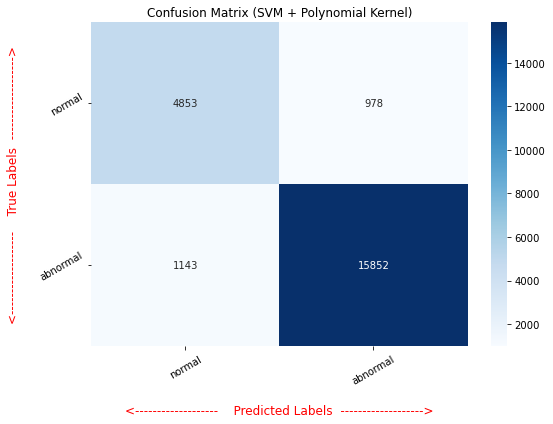

In [15]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("Confusion Matrix (SVM + Polynomial Kernel)")
plt.tight_layout()
plt.show()

##### _2. RBF_

In [16]:
rbf = svm.SVC(kernel='rbf', gamma=0.5, C=0.1).fit(X_train, y_train)
rbf_pred = rbf.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)
rbf_f1 = f1_score(y_test, rbf_pred, average='weighted')
print('\n Accuracy (RBF Kernel): ', "%.2f" % (rbf_accuracy*100))
print('\n F1 (RBF Kernel): ', "%.2f" % (rbf_f1*100))


 Accuracy (RBF Kernel):  90.88

 F1 (RBF Kernel):  90.83


In [17]:
y_pred = rbf.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\nClassification Report (SVM + RBF Kernel):\n")
print(classification_report(y_valid, y_pred))


Classification Report (SVM + RBF Kernel):

              precision    recall  f1-score   support

       False       0.82      0.81      0.81      5831
        True       0.93      0.94      0.94     16995

    accuracy                           0.91     22826
   macro avg       0.88      0.87      0.88     22826
weighted avg       0.90      0.91      0.91     22826



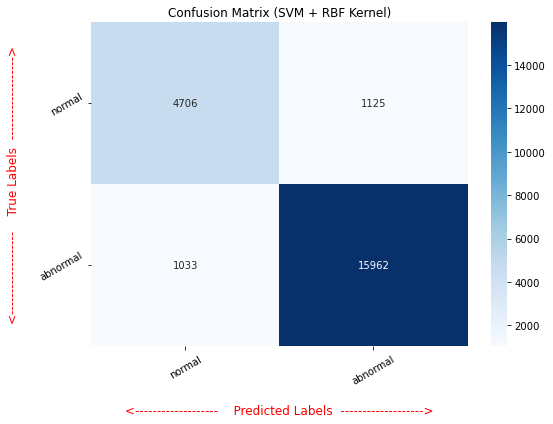

In [18]:
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("Confusion Matrix (SVM + RBF Kernel)")
plt.tight_layout()
plt.show()